# Best fixed models learning curve comparison

Notebook này so sánh learning curve của các model với một cấu hình phù hợp cố định cho mỗi model.

Nguyên tắc so sánh:

- Mỗi model dùng đúng cùng `train_size` tại từng điểm learning curve.
- Mỗi model dùng đúng cùng full `X_val` và full `X_test` ở mọi điểm learning curve.
- Mỗi model dùng đúng cùng full `X_train`, full `X_val`, full `X_test` ở bảng đánh giá cuối.
- Test curve chỉ để diagnostic; không dùng test để chọn model/tham số.
- Không sweep nhiều tham số trong notebook này.

In [1]:
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)

## 1. Load data

In [2]:
DATA_PATH = Path('../processed_data/model_ready/gdsc2_lgbm_style_data.npz')
METADATA_PATH = Path('../processed_data/model_ready/artifacts/gdsc2_lgbm_style_metadata.json')
OUTPUT_DIR = Path('../models/best_models_learning_curve_comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

loaded = np.load(DATA_PATH)
X_train = loaded['X_train']
y_train = loaded['y_train']
X_val = loaded['X_val']
y_val = loaded['y_val']
X_test = loaded['X_test']
y_test = loaded['y_test']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)
metadata

X_train: (65239, 1477) y_train: (65239,)
X_val:   (9233, 1477) y_val:   (9233,)
X_test:  (18231, 1477) y_test:  (18231,)


{'dataset': 'GDSC2',
 'split_method': 'cold_split by Cell Line_ID',
 'random_state': 42,
 'drug_feature': 'Morgan fingerprint 1024 bits',
 'cell_feature': 'StandardScaler + PCA fitted on train cell lines only',
 'cell_pca_components': 453,
 'X_train_shape': [65239, 1477],
 'X_val_shape': [9233, 1477],
 'X_test_shape': [18231, 1477],
 'saved_npz': '../processed_data/model_ready/gdsc2_lgbm_style_data.npz'}

## 2. Fixed model configs

`RandomForest` và `KNN` chạy cùng full train/val/test như các model khác để so sánh công bằng. KNN có thể rất lâu vì phải tính khoảng cách tới toàn bộ train set.

In [3]:
RANDOM_STATE = 42
TRAIN_FRACTIONS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

# Một cấu hình hợp lý cố định cho từng model, không sweep tham số.
models = {
    'linear': LinearRegression(),
    'ridge': Ridge(alpha=100.0),
    'lasso': Lasso(
        alpha=0.001,
        max_iter=5000,
        tol=1e-3,
        selection='random',
        random_state=RANDOM_STATE,
    ),
    'random_forest': RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    'knn': KNeighborsRegressor(
        n_neighbors=31,
        weights='distance',
        metric='minkowski',
        p=2,
        n_jobs=-1,
    ),
}

rng = np.random.default_rng(RANDOM_STATE)
train_perm = rng.permutation(len(y_train))
list(models.keys())

['linear', 'ridge', 'lasso', 'random_forest', 'knn']

## 3. Helpers

In [4]:
def safe_corr(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def compute_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': safe_corr(y_true, y_pred),
    }


def run_learning_curve(model_name, base_model):
    rows = []
    n_train = len(y_train)

    for fraction in TRAIN_FRACTIONS:
        sample_size = max(20, int(n_train * fraction))
        sample_idx = train_perm[:sample_size]

        model = clone(base_model)
        start = time.time()
        model.fit(X_train[sample_idx], y_train[sample_idx])
        fit_seconds = time.time() - start

        train_pred = model.predict(X_train[sample_idx])
        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)

        train_metrics = compute_metrics(y_train[sample_idx], train_pred)
        val_metrics = compute_metrics(y_val, val_pred)
        test_metrics = compute_metrics(y_test, test_pred)

        rows.append({
            'model': model_name,
            'train_fraction': fraction,
            'train_size': sample_size,
            'val_size': len(y_val),
            'test_size': len(y_test),
            'fit_seconds': fit_seconds,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}': v for k, v in val_metrics.items()},
            **{f'test_{k}': v for k, v in test_metrics.items()},
        })

    return pd.DataFrame(rows)


def fit_full_train_eval_test(model_name, base_model):
    model = clone(base_model)
    start = time.time()
    model.fit(X_train, y_train)
    fit_seconds = time.time() - start

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    row = {
        'model': model_name,
        'train_size': len(y_train),
        'val_size': len(y_val),
        'test_size': len(y_test),
        'fit_seconds': fit_seconds,
        **{f'train_{k}': v for k, v in compute_metrics(y_train, train_pred).items()},
        **{f'val_{k}': v for k, v in compute_metrics(y_val, val_pred).items()},
        **{f'test_{k}': v for k, v in compute_metrics(y_test, test_pred).items()},
    }

    joblib.dump(model, OUTPUT_DIR / f'{model_name}.joblib')
    np.save(OUTPUT_DIR / f'{model_name}_val_pred.npy', val_pred)
    np.save(OUTPUT_DIR / f'{model_name}_test_pred.npy', test_pred)

    return row

## 4. Learning curves on full validation set

In [5]:
curve_parts = []

for model_name, model in models.items():
    print('Learning curve for', model_name)
    curve_parts.append(run_learning_curve(model_name, model))

learning_curve_df = pd.concat(curve_parts, ignore_index=True)

size_check = (
    learning_curve_df
    .groupby('train_fraction')
    .agg(
        n_models=('model', 'nunique'),
        n_train_sizes=('train_size', 'nunique'),
        n_val_sizes=('val_size', 'nunique'),
        n_test_sizes=('test_size', 'nunique'),
        train_size=('train_size', 'first'),
        val_size=('val_size', 'first'),
        test_size=('test_size', 'first'),
    )
)

assert (size_check['n_models'] == len(models)).all()
assert (size_check['n_train_sizes'] == 1).all()
assert (size_check['n_val_sizes'] == 1).all()
assert (size_check['n_test_sizes'] == 1).all()

display(size_check)
display(learning_curve_df.round(4))
learning_curve_df.to_csv(OUTPUT_DIR / 'best_fixed_models_learning_curves.csv', index=False)

Learning curve for linear
Learning curve for ridge


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.135528955539485e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.329330742322782e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Learning curve for lasso
Learning curve for random_forest
Learning curve for knn


,n_models,n_train_sizes,n_val_sizes,n_test_sizes,train_size,val_size,test_size
train_fraction,,,,,,,
0.1,5,1,1,1,6523,9233,18231
0.2,5,1,1,1,13047,9233,18231
0.4,5,1,1,1,26095,9233,18231
0.6,5,1,1,1,39143,9233,18231
0.8,5,1,1,1,52191,9233,18231
1.0,5,1,1,1,65239,9233,18231


,model,train_fraction,train_size,val_size,test_size,fit_seconds,train_rmse,train_mae,train_r2,train_pearson,val_rmse,val_mae,val_r2,val_pearson,test_rmse,test_mae,test_r2,test_pearson
0,linear,0.1,6523,9233,18231,0.3476,1.1401,0.8620,0.8256,0.9086,1.3496,1.0245,0.7449,0.8652,1.3927,1.0529,0.7377,0.8593
1,linear,0.2,13047,9233,18231,0.7308,1.1598,0.8710,0.8169,0.9038,1.3248,1.0029,0.7542,0.8710,1.3753,1.0412,0.7442,0.8629
2,linear,0.4,26095,9233,18231,1.2354,1.1787,0.8831,0.8112,0.9007,1.3189,0.9983,0.7563,0.8716,1.3679,1.0347,0.7470,0.8645
3,linear,0.6,39143,9233,18231,1.6667,1.1992,0.8944,0.8055,0.8975,1.3262,1.0016,0.7536,0.8699,1.3748,1.0387,0.7444,0.8630
4,linear,0.8,52191,9233,18231,2.0339,1.2061,0.8992,0.8034,0.8963,1.3327,1.0065,0.7512,0.8687,1.3759,1.0390,0.7440,0.8628
5,linear,1.0,65239,9233,18231,2.5254,1.2661,0.9539,0.7845,0.8857,1.3798,1.0530,0.7333,0.8584,1.4256,1.0855,0.7252,0.8518
6,ridge,0.1,6523,9233,18231,0.0805,1.1554,0.8795,0.8209,0.9068,1.3519,1.0346,0.7440,0.8648,1.4015,1.0667,0.7344,0.8577
7,ridge,0.2,13047,9233,18231,0.1418,1.1643,0.8776,0.8154,0.9033,1.3253,1.0075,0.7539,0.8708,1.3783,1.0461,0.7431,0.8623
8,ridge,0.4,26095,9233,18231,0.3409,1.1783,0.8841,0.8114,0.9008,1.3159,0.9975,0.7574,0.8721,1.3677,1.0356,0.7471,0.8645
9,ridge,0.6,39143,9233,18231,0.8622,1.1900,0.8898,0.8085,0.8992,1.3120,0.9940,0.7589,0.8728,1.3634,1.0326,0.7487,0.8654


## 5. Full train / val / test metrics

Test set chỉ được dùng ở đây, sau khi model fit trên full training set.

In [6]:
full_eval_rows = []

for model_name, model in models.items():
    print('Full train/test eval for', model_name)
    full_eval_rows.append(fit_full_train_eval_test(model_name, model))

full_eval_df = pd.DataFrame(full_eval_rows).sort_values('val_rmse')

assert full_eval_df['train_size'].nunique() == 1
assert full_eval_df['val_size'].nunique() == 1
assert full_eval_df['test_size'].nunique() == 1

display(full_eval_df[['model', 'train_size', 'val_size', 'test_size']])
display(full_eval_df.round(4))
full_eval_df.to_csv(OUTPUT_DIR / 'best_fixed_models_full_eval.csv', index=False)

Full train/test eval for linear
Full train/test eval for ridge


/opt/anaconda3/envs/llms/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.329481377382763e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Full train/test eval for lasso
Full train/test eval for random_forest
Full train/test eval for knn


,model,train_size,val_size,test_size
1,ridge,65239,9233,18231
2,lasso,65239,9233,18231
0,linear,65239,9233,18231
3,random_forest,65239,9233,18231
4,knn,65239,9233,18231


,model,train_size,val_size,test_size,fit_seconds,train_rmse,train_mae,train_r2,train_pearson,val_rmse,val_mae,val_r2,val_pearson,test_rmse,test_mae,test_r2,test_pearson
1,ridge,65239,9233,18231,0.6270,1.1975,0.8944,0.8072,0.8985,1.3133,0.9936,0.7584,0.8728,1.3606,1.0301,0.7497,0.8660
2,lasso,65239,9233,18231,7.1941,1.1986,0.8957,0.8069,0.8983,1.3138,0.9946,0.7582,0.8727,1.3618,1.0312,0.7492,0.8658
0,linear,65239,9233,18231,2.5835,1.2660,0.9538,0.7845,0.8857,1.3797,1.0529,0.7333,0.8585,1.4255,1.0854,0.7252,0.8518
3,random_forest,65239,9233,18231,23.6973,0.5883,0.4246,0.9535,0.9795,1.3904,1.0502,0.7292,0.8560,1.3814,1.0394,0.7420,0.8614
4,knn,65239,9233,18231,0.0122,0.0687,0.0064,0.9994,0.9997,2.5830,1.9499,0.0654,0.2892,2.6850,2.0067,0.0252,0.2777


## 6. Big combined learning curve plot

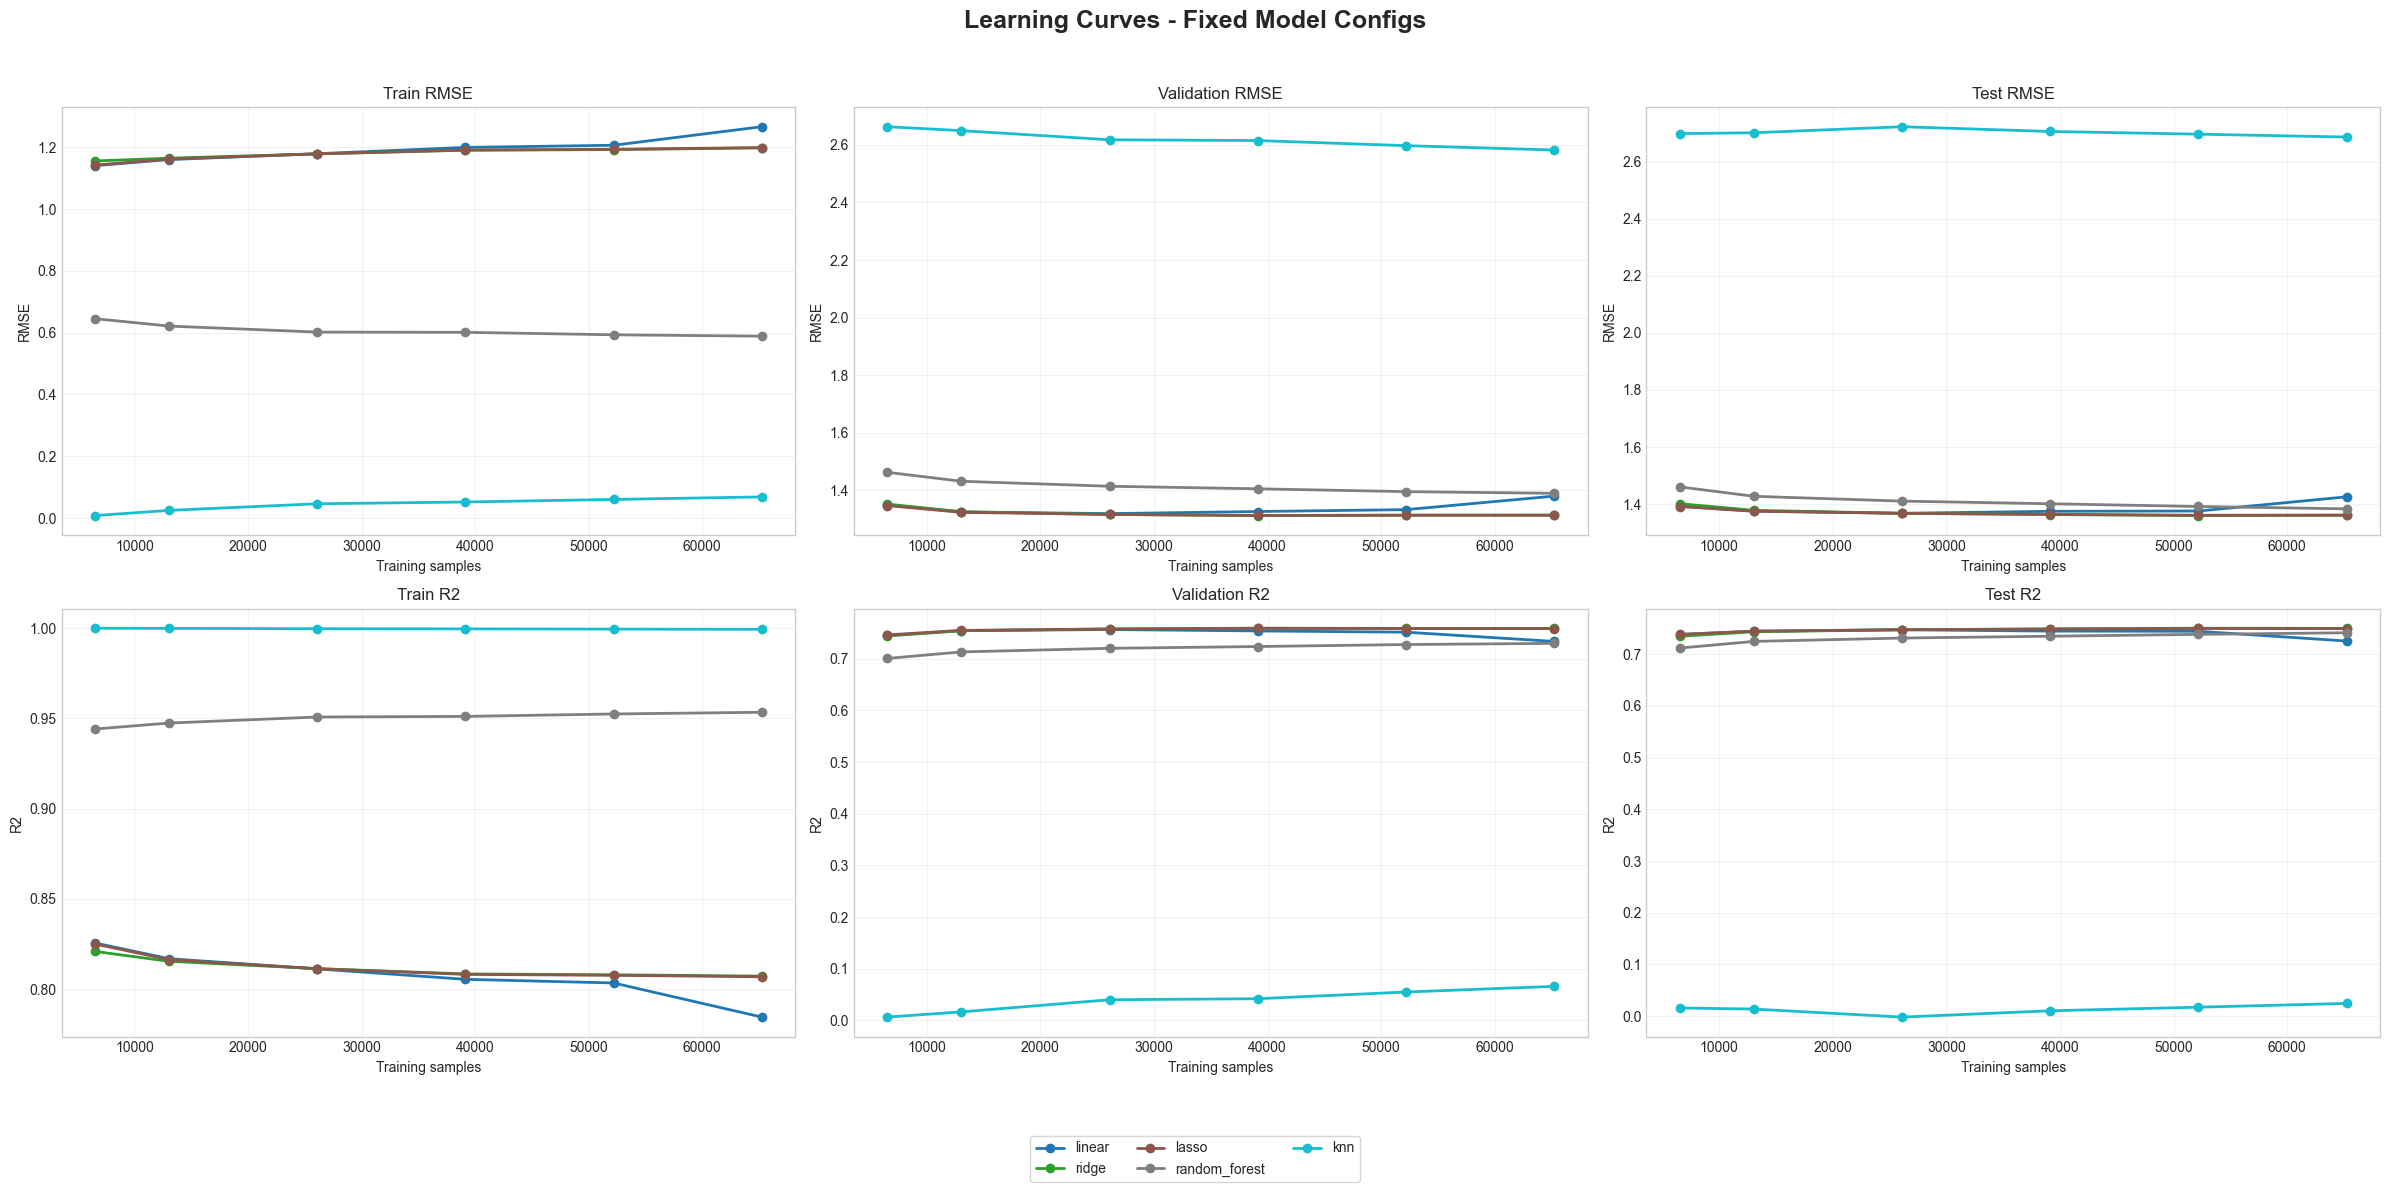

In [7]:
models_order = list(models.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(models_order)))
color_map = dict(zip(models_order, colors))

fig, axes = plt.subplots(2, 3, figsize=(24, 12))

plot_specs = [
    (axes[0, 0], 'train_rmse', 'Train RMSE', 'RMSE'),
    (axes[0, 1], 'val_rmse', 'Validation RMSE', 'RMSE'),
    (axes[0, 2], 'test_rmse', 'Test RMSE', 'RMSE'),
    (axes[1, 0], 'train_r2', 'Train R2', 'R2'),
    (axes[1, 1], 'val_r2', 'Validation R2', 'R2'),
    (axes[1, 2], 'test_r2', 'Test R2', 'R2'),
]
for model_name in models_order:
    model_df = learning_curve_df[learning_curve_df['model'] == model_name].sort_values('train_size')
    for ax, metric_col, _, _ in plot_specs:
        ax.plot(
            model_df['train_size'],
            model_df[metric_col],
            marker='o',
            linewidth=2,
            label=model_name,
            color=color_map[model_name],
        )

for ax, _, title, ylabel in plot_specs:
    ax.set_title(title)
    ax.set_xlabel('Training samples')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=True)
fig.suptitle('Learning Curves - Fixed Model Configs', fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'best_fixed_models_learning_curves_big_plot.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Train/Validation RMSE only

Test set không có learning curve riêng; test chỉ được dùng ở bảng đánh giá cuối sau khi fit trên full training set.

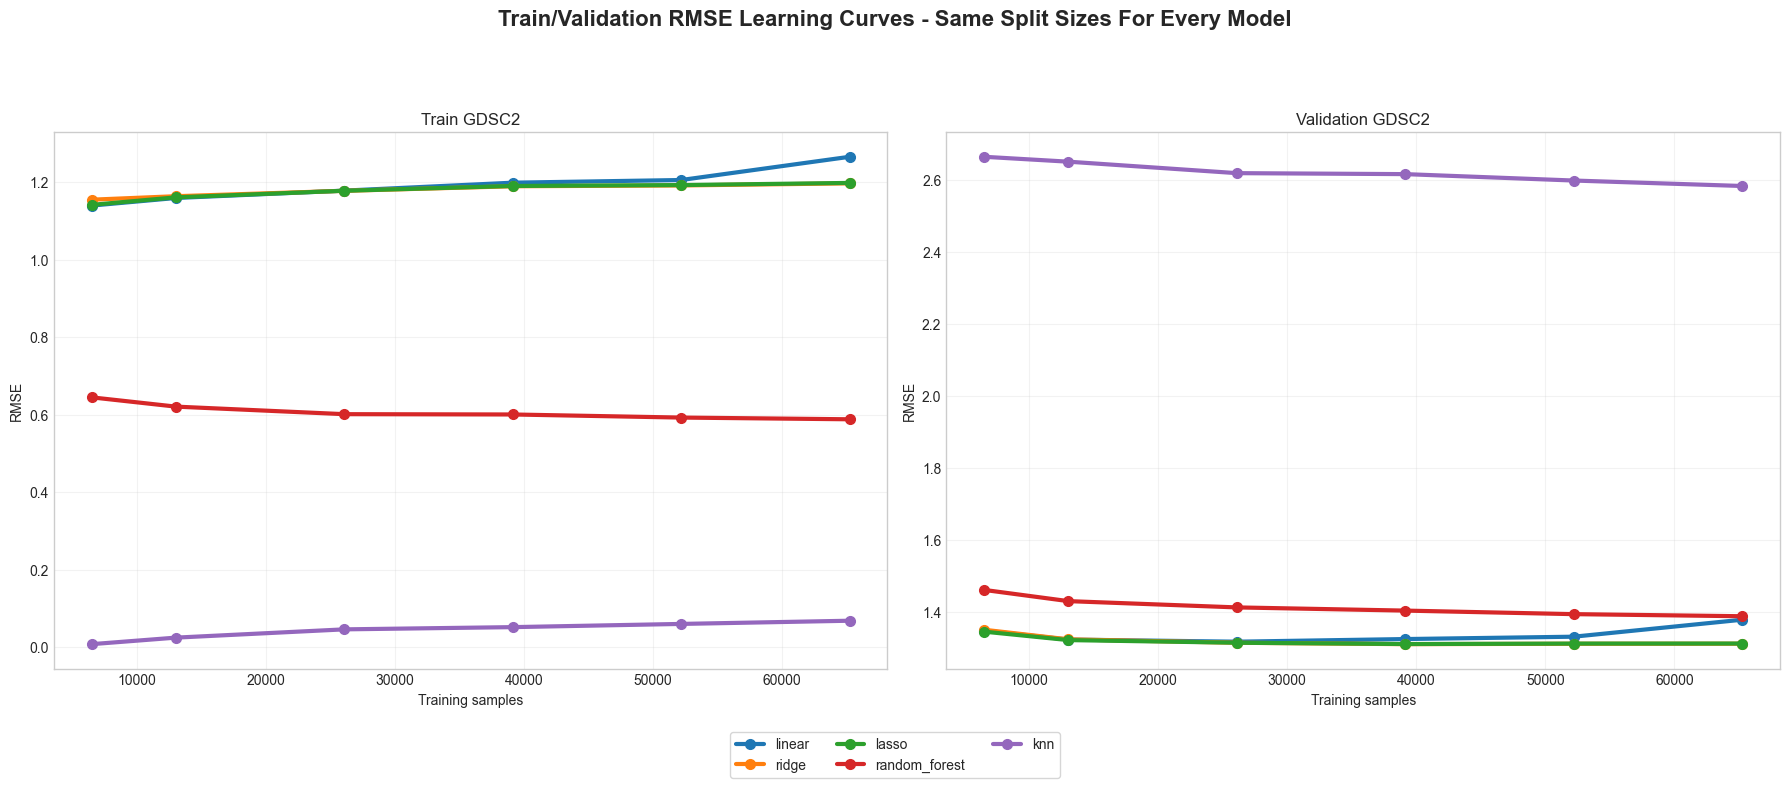

In [10]:
plot_df = learning_curve_df[['model', 'train_size', 'train_rmse', 'val_rmse']].copy()
models_order = list(models.keys())
color_map = {
    'linear': '#1f77b4',
    'ridge': '#ff7f0e',
    'lasso': '#2ca02c',
    'random_forest': '#d62728',
    'knn': '#9467bd',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), sharey=False)

for model_name in models_order:
    model_df = plot_df[plot_df['model'] == model_name].sort_values('train_size')
    axes[0].plot(
        model_df['train_size'],
        model_df['train_rmse'],
        marker='o',
        linewidth=3.0,
        markersize=7,
        label=model_name,
        color=color_map[model_name],
    )
    axes[1].plot(
        model_df['train_size'],
        model_df['val_rmse'],
        marker='o',
        linewidth=3.0,
        markersize=7,
        label=model_name,
        color=color_map[model_name],
    )

axes[0].set_title('Train GDSC2')
axes[1].set_title('Validation GDSC2')
for ax in axes:
    ax.set_xlabel('Training samples')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='y', labelleft=True)
    ax.grid(True, alpha=0.25)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=True)
fig.suptitle('Train/Validation RMSE Learning Curves - Same Split Sizes For Every Model', y=1.03, fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'train_validation_rmse_learning_curve.png', dpi=200, bbox_inches='tight')
plt.show()
